# 🌌 Stellar Object Classification

**Goal:** Classify celestial objects into **Stars, Galaxies and Quasars** using machine learning.

**Workflow:** Load Data → EDA → Clean Data → Feature Engineering → Split Data → Train Models → Evaluate → Compare Models → Save Best Model


## 1. Import Libraries

**Procedure:** Load the libraries needed for data analysis, visualization and machine learning.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import joblib

sns.set_theme(style="whitegrid")


## 2. Load Dataset

**Procedure:** Read the CSV file and display the first few records.

In [28]:
df = pd.read_csv("star_classification.csv")
print("Shape:", df.shape)
df.head()



Shape: (100000, 18)


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


## 3. Understand the Data

**Procedure:** Check columns, data types and missing values.

In [29]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7), str(1)
mem

## 4. Check Target Classes

**Procedure:** View the number of objects in each class.

<Axes: xlabel='class', ylabel='count'>

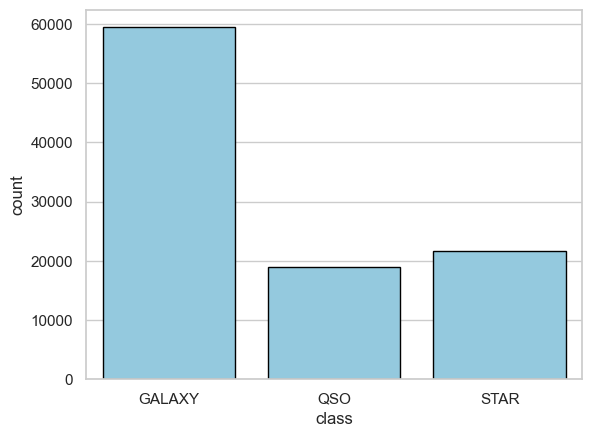

In [30]:
sns.countplot(
    data=df,
    x="class",
    color="skyblue",
    edgecolor="black",
    linewidth=1
)


## 5. Clean the Data

**Procedure:** Remove duplicate rows and missing records.

In [31]:
df = df.drop_duplicates()
df = df.dropna()

print("New shape:", df.shape)


New shape: (100000, 18)


## 5. understanding photometric features distributions

**Procedure:** Select photometric features and visualize their distributions using histograms to understand their patterns and variability.

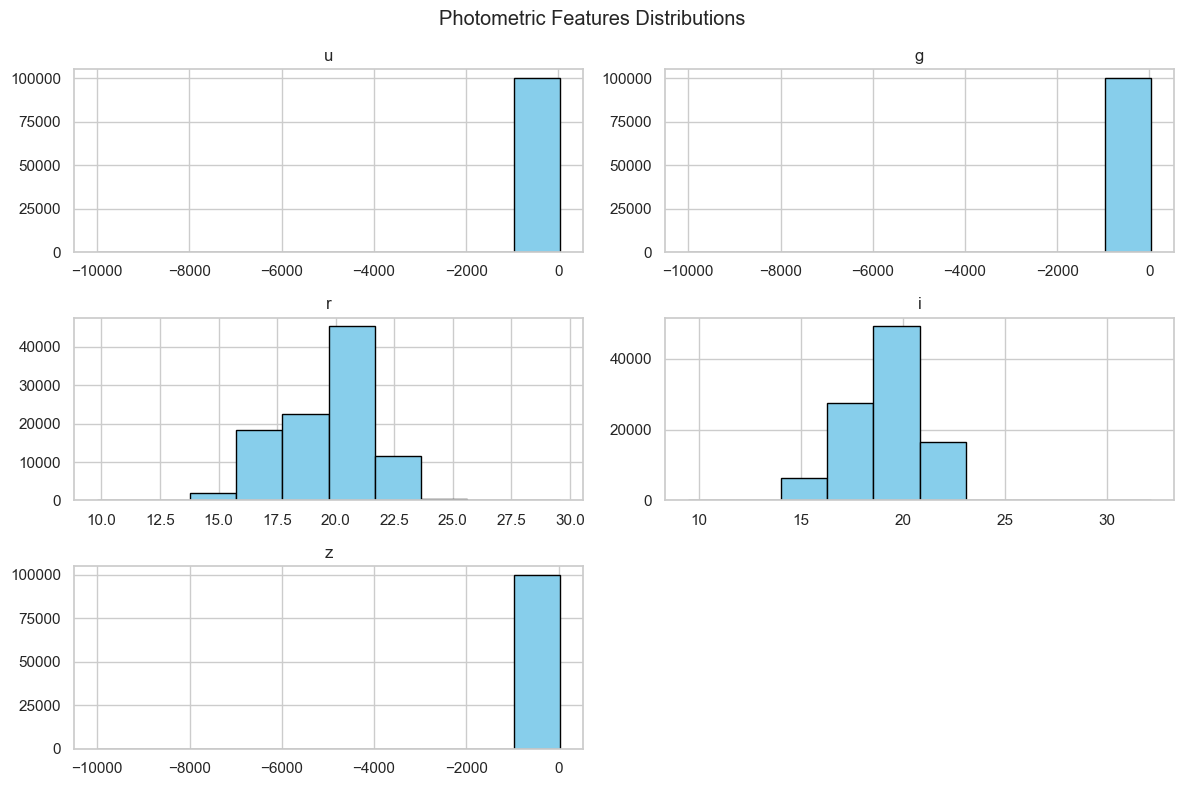

In [32]:

import matplotlib.pyplot as plt

features = ['u', 'g', 'r', 'i', 'z']

df[features].hist(
    figsize=(12, 8),
    color='skyblue',
    edgecolor='black'
)

plt.suptitle('Photometric Features Distributions')

plt.tight_layout()

plt.show()


## 7.  Understanding Redshift vs Class

**Procedure:** Compare redshift values across different object classes to understand their distribution and relationship.



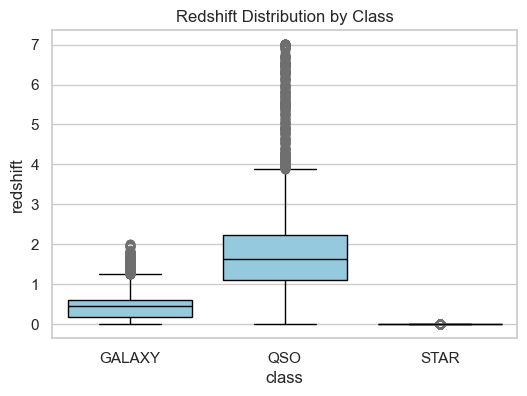

In [33]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    x='class',
    y='redshift',
    data=df,
    color='skyblue',
    boxprops=dict(edgecolor='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black')
)

plt.title('Redshift Distribution by Class')

plt.show()

## 8. Correlation Analysis

**Procedure:** Identify relationships between numerical features.

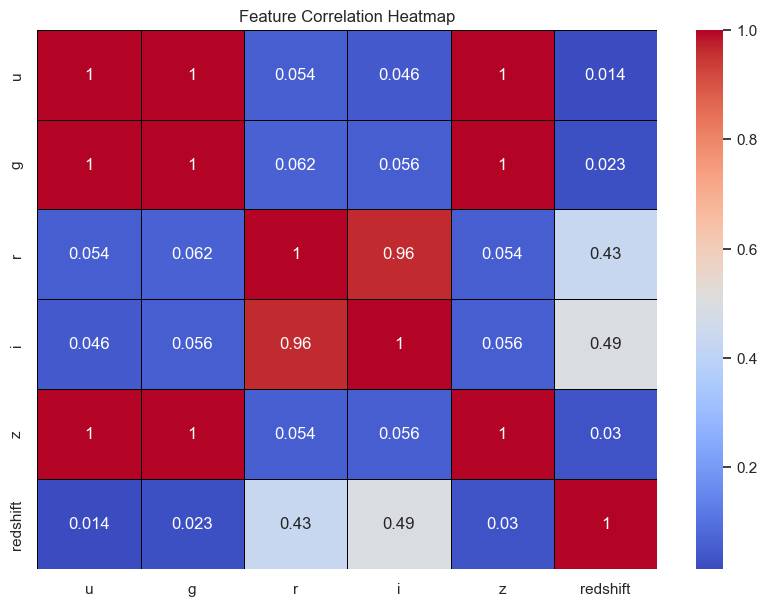

In [34]:
# Select numerical features
features = ['u', 'g', 'r', 'i', 'z', 'redshift']

# Calculate correlation matrix
correlation_matrix = df[features].corr()

# Create heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2g',
    linewidths=0.5,
    linecolor='black',
    cbar=True
)

plt.title('Feature Correlation Heatmap')

plt.show()

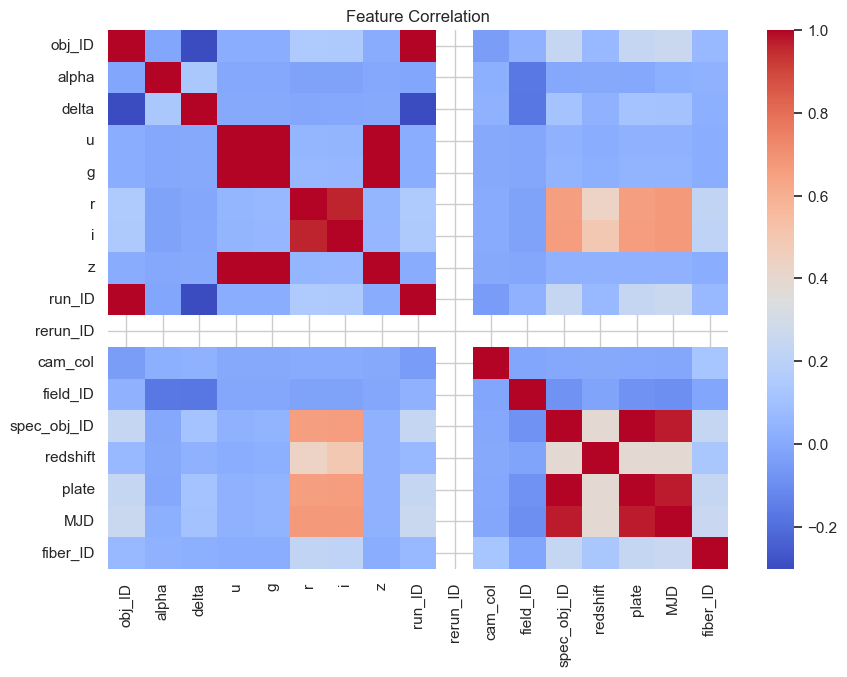

In [35]:
corr = df.select_dtypes("number").corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()


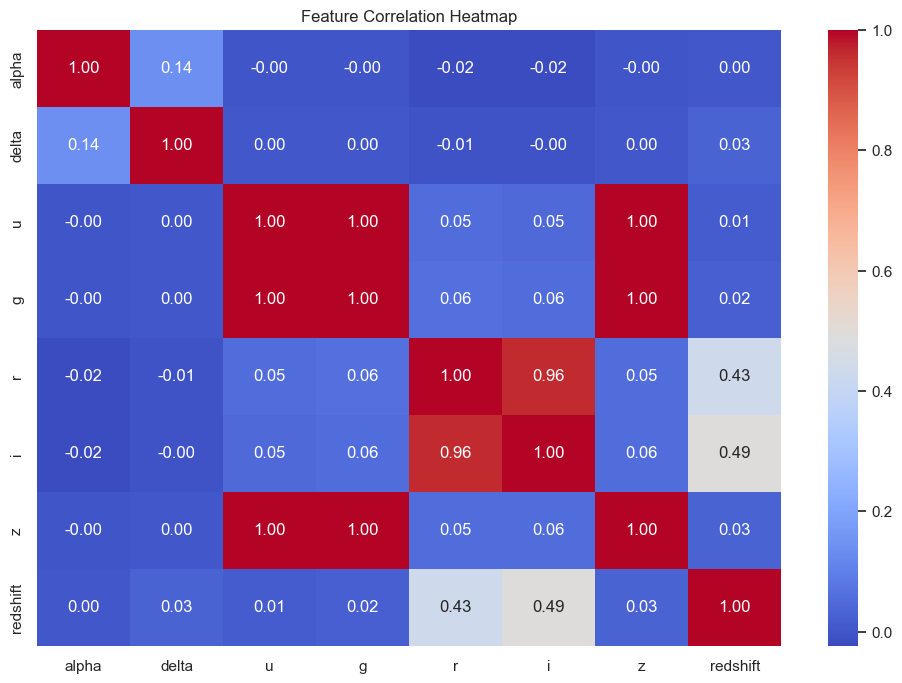

In [36]:

# Select numerical features
features = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

# Calculate correlation
corr = df[features].corr()

# Create heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap')

plt.show()

## 9. Select Features and Target

**Procedure:** Separate the input features from the class we want to predict.

In [37]:
X = df.drop(columns=["class"])
print(X.columns.tolist())
y = df["class"]

# Remove ID columns if they exist
id_cols = [c for c in X.columns if "id" in c.lower()]
X = X.drop(columns=id_cols, errors="ignore")

print("Features:", X.columns.tolist())


['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'redshift', 'plate', 'MJD', 'fiber_ID']
Features: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'cam_col', 'redshift', 'plate', 'MJD']


## 10. Encode Target

**Procedure:** Convert class names into numerical labels for machine learning.

In [38]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Classes:", encoder.classes_)


Classes: ['GALAXY' 'QSO' 'STAR']


## 11. Split the Data

**Procedure:** Use 80% of the data for training and 20% for testing.

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (80000, 11)
Testing data: (20000, 11)


## 12. Scale Features

**Procedure:** Standardize numerical features so distance- and margin-based models work properly.

In [40]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## 13. Decision Tree

**Procedure:** Train a Decision Tree classifier and measure its performance.

In [41]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))


Decision Tree Accuracy: 0.96565


## 14. Random Forest

**Procedure:** Train a Random Forest classifier using multiple decision trees.

In [42]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))


Random Forest Accuracy: 0.98055


## 15. K-Nearest Neighbors

**Procedure:** Classify objects based on nearby training observations.

In [43]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))


KNN Accuracy: 0.92905


## 16. Support Vector Machine

**Procedure:** Train an SVM classifier to separate the object classes.

In [44]:
svm = SVC()
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))


SVM Accuracy: 0.96055


## 17. Gradient Boosting

**Procedure:** Train a boosting model that improves predictions through sequential trees.

In [45]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))


Gradient Boosting Accuracy: 0.97765


## 18. AdaBoost

**Procedure:** Train an AdaBoost classifier using a sequence of weak learners.

In [46]:
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)

ada_pred = ada.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, ada_pred))


AdaBoost Accuracy: 0.8591


## 19. XGBoost

**Procedure:** Train XGBoost as the final boosting model required by the project.

In [47]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))


XGBoost Accuracy: 0.9788


## 20. Compare Models

**Procedure:** Compare all models using accuracy, precision, recall and F1-score.

In [48]:
models = {
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "KNN": knn_pred,
    "SVM": svm_pred,
    "Gradient Boosting": gb_pred,
    "AdaBoost": ada_pred,
    "XGBoost": xgb_pred
}

results = []

for name, pred in models.items():
    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred, average="weighted"),
        recall_score(y_test, pred, average="weighted"),
        f1_score(y_test, pred, average="weighted")
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

results_df.sort_values("F1 Score", ascending=False)


,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.98055,0.980463,0.98055,0.980441
6,XGBoost,0.97880,0.978712,0.97880,0.978697
4,Gradient Boosting,0.97765,0.977575,0.97765,0.977469
0,Decision Tree,0.96565,0.965823,0.96565,0.965727
3,SVM,0.96055,0.960838,0.96055,0.960338
2,KNN,0.92905,0.929869,0.92905,0.928671
5,AdaBoost,0.85910,0.882762,0.85910,0.865141


## 21. Visualize Model Comparison

**Procedure:** Create a simple comparison chart for model performance.

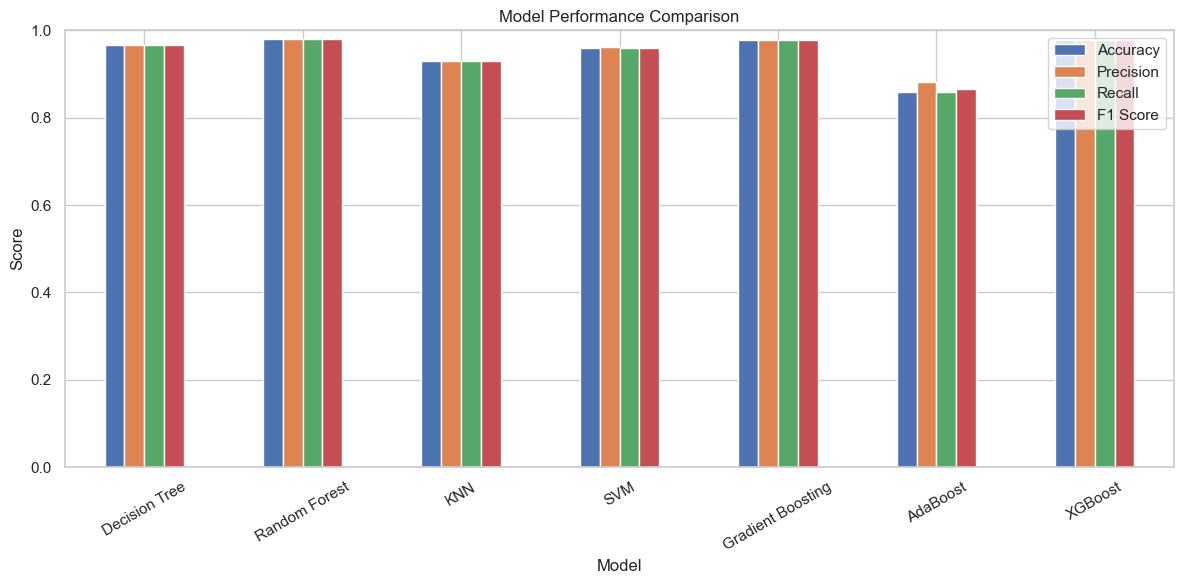

In [49]:
results_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    kind="bar",
    figsize=(12, 6)
)

plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 22. Detailed Evaluation

**Procedure:** Inspect the classification report and confusion matrix for the best model.

Best Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.97      0.94      0.95      3792
        STAR       0.99      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000



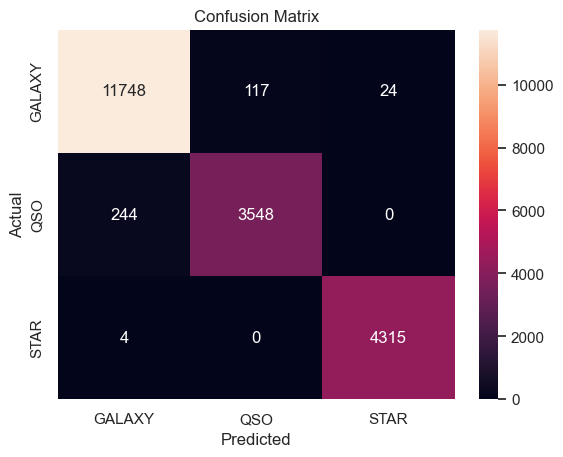

In [50]:
best_model_name = results_df.sort_values(
    "F1 Score", ascending=False
).iloc[0]["Model"]

best_predictions = models[best_model_name]

print("Best Model:", best_model_name)

print("\nClassification Report:")
print(classification_report(
    y_test,
    best_predictions,
    target_names=encoder.classes_
))

cm = confusion_matrix(y_test, best_predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 23. Feature Importance

**Procedure:** Identify the features that contribute most to Random Forest classification.

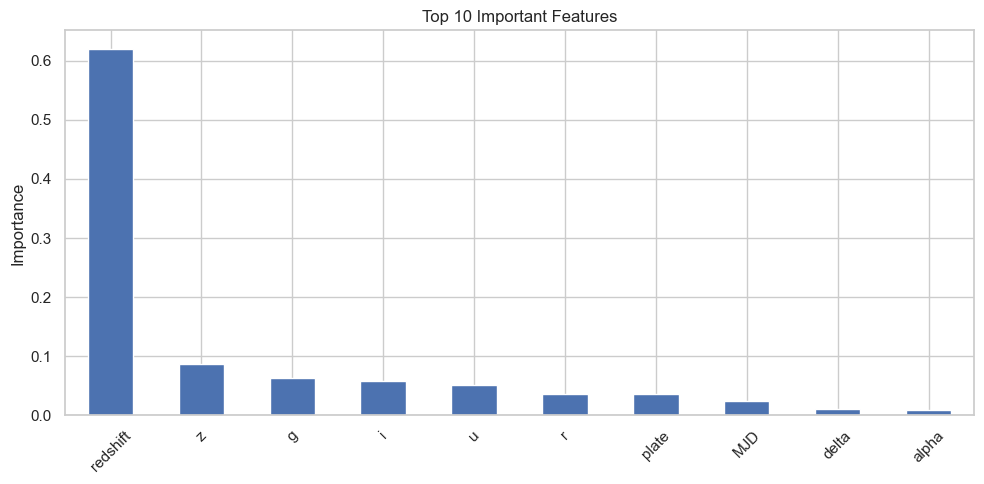

In [51]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(10).plot(kind="bar", figsize=(10, 5))

plt.title("Top 10 Important Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 24. Save the Best Model

**Procedure:** Save the trained model and label encoder for future predictions.

In [52]:
models_folder = r"C:\Users\acer\OneDrive\Desktop\Sowndharya_Stellar_Classification\stellar classification"

joblib.dump(rf, f"{models_folder}/stellar_random_forest.pkl")
joblib.dump(scaler, f"{models_folder}/scaler.pkl")
joblib.dump(encoder, f"{models_folder}/label_encoder.pkl")

results_df.to_csv(
    f"{models_folder}/model_comparison.csv",
    index=False
)

print("Model files saved successfully!")


Model files saved successfully!


# ✅ Final Project Output

After running all cells, my project contains:

- Cleaned dataset analysis
- EDA visualizations
- Feature engineering
- 7 classification algorithms
- Accuracy, precision, recall and F1-score
- Model comparison
- Confusion matrix
- Feature importance
- Saved model

